In [157]:
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
from fitter import Fitter, get_common_distributions, get_distributions
import pandas as pd
import seaborn as sns
import numpy as np


# 1. Read the dataset

In [158]:
df = pl.read_csv("https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv")

# 2. Set the 'time' column as the index. 
Note: Polars does not have a built-in index like pandas, but we can sort the DataFrame by the 'time' column to ensure it is in the correct order for time series analysis.

In [159]:
df = df.drop("")
df = df.with_columns(
    pl.col("time").str.to_datetime()
)
df = df.sort("time")

# 3. Dataset information

In [160]:
print((df.schema))

(df.describe()).show()


Schema({'time': Datetime(time_unit='us', time_zone=None), 'open': Float64, 'high': Float64, 'low': Float64, 'close': Float64, 'tick_volume': Int64, 'spread': Int64, 'real_volume': Int64, 'MeanCloseOpen': Float64, 'Diff_Close': Float64, 'Diff_Open': Float64, 'Diff_MeanCloseOpen': Float64})


statistic,time,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""5000""",5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""","""2022-12-18 06:55:24.240000""",1.043891,1.044815,1.042991,1.043906,3690.2494,8.9816,0.0,1.043898,0.000012,0.000012,0.000012
"""std""",null,0.041135,0.040991,0.041263,0.041135,2800.488505,5.785115,0.0,0.041129,0.0014,0.001404,0.000978
"""min""","""2022-07-25 13:00:00""",0.95391,0.95593,0.95357,0.95391,85.0,0.0,0.0,0.954735,-0.01397,-0.01401,-0.00726


# 4. Null and nan values

In [161]:
null_count = df.null_count().sum()
nan_count = df.select(cs.numeric().is_nan().sum()).sum()

print(f"Null values: {null_count}")
print(f"NaN values: {nan_count}")


Null values: shape: (1, 12)
┌──────┬──────┬──────┬─────┬───┬───────────────┬────────────┬───────────┬────────────────────┐
│ time ┆ open ┆ high ┆ low ┆ … ┆ MeanCloseOpen ┆ Diff_Close ┆ Diff_Open ┆ Diff_MeanCloseOpen │
│ ---  ┆ ---  ┆ ---  ┆ --- ┆   ┆ ---           ┆ ---        ┆ ---       ┆ ---                │
│ u32  ┆ u32  ┆ u32  ┆ u32 ┆   ┆ u32           ┆ u32        ┆ u32       ┆ u32                │
╞══════╪══════╪══════╪═════╪═══╪═══════════════╪════════════╪═══════════╪════════════════════╡
│ 0    ┆ 0    ┆ 0    ┆ 0   ┆ … ┆ 0             ┆ 0          ┆ 0         ┆ 0                  │
└──────┴──────┴──────┴─────┴───┴───────────────┴────────────┴───────────┴────────────────────┘
NaN values: shape: (1, 11)
┌──────┬──────┬─────┬───────┬───┬───────────────┬────────────┬───────────┬────────────────────┐
│ open ┆ high ┆ low ┆ close ┆ … ┆ MeanCloseOpen ┆ Diff_Close ┆ Diff_Open ┆ Diff_MeanCloseOpen │
│ ---  ┆ ---  ┆ --- ┆ ---   ┆   ┆ ---           ┆ ---        ┆ ---       ┆ ---          

# 5. Use PascalCase for column names

In [162]:
columns = df.columns
new_columns = [col.title().replace("_", "") if "MeanCloseOpen" not in col else col.replace("_", "") for col in columns]

df = df.rename(dict(zip(columns, new_columns)))

print(df.columns)

['Time', 'Open', 'High', 'Low', 'Close', 'TickVolume', 'Spread', 'RealVolume', 'MeanCloseOpen', 'DiffClose', 'DiffOpen', 'DiffMeanCloseOpen']


# 6. Add new column named 'DiffPrice' that contains the difference between 'Close' and 'Open' prices.

In [163]:
df = df.with_columns(
    (pl.col("Close") - pl.col("Open")).alias("DiffPrice")
).select(["Time", "Close", "DiffPrice"])

# Distribution of 'DiffPrice'

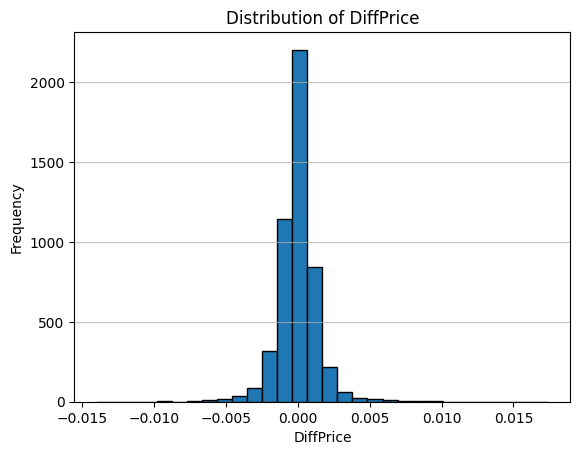

In [164]:
plt.hist(df["DiffPrice"], bins=30, edgecolor="black")
plt.title("Distribution of DiffPrice")
plt.xlabel("DiffPrice")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)
plt.show()

# Determine the best distribution for 'DiffPrice'


2026-03-17 22:24:40.151 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted beta: error=108464.513883, AIC=-51566.63, KS=0.0905
2026-03-17 22:24:40.228 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted powerlaw: error=804573.020498, AIC=-34813.14, KS=0.5169
2026-03-17 22:24:40.232 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted uniform: error=805090.164254, AIC=-34618.22, KS=0.4452
2026-03-17 22:24:40.248 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted expon: error=850881.102365, AIC=-32694.13, KS=0.5313
2026-03-17 22:24:40.275 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=929279.248348, AIC=-17464.79, KS=0.5917
2026-03-17 22:24:40.359 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted cauchy: error=23676.582640, AIC=-52558.81, KS=0.0424
2026-03-17 22:24:40.379 | WARNING  | fitter.fitter:_fit_single_distribution:422 - SKIPPED burrnorm: AttributeError (timeout=30s or fitting faile

The best distribution for 'DiffPrice' is: {'cauchy': {'loc': np.float64(4.2206479556625715e-06), 'scale': np.float64(0.0005686465972643281)}}


2026-03-17 22:24:40.602 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted exponpow: error=684562.099979, AIC=-39133.16, KS=0.5331


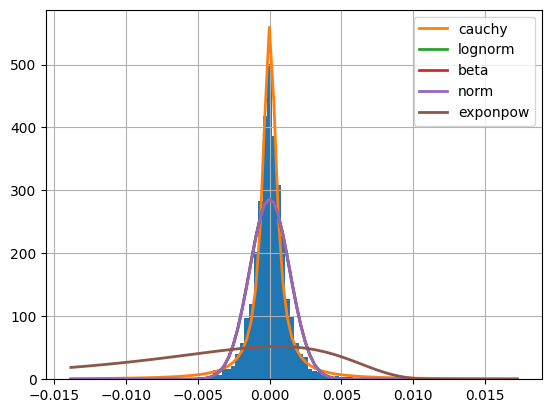

In [165]:
data = df["DiffPrice"].to_numpy()

distributions = (get_common_distributions() + [dist for dist in ['gamma', 'lognorm', "beta", "burr" "norm"] if dist not in get_common_distributions()])  

f = Fitter(data,
           distributions=distributions)
f.fit()
f.summary()

f.get_best(method="sumsquare_error")

f.fitted_param["beta"]

print(f"The best distribution for 'DiffPrice' is: {f.get_best(method='sumsquare_error')}")

# 7. Select data from 2023

In [166]:
df_2023 = df.filter(pl.col("Time").dt.year() == 2023).sort("Time", descending=False)

# 8. Mean with periodicity of 15 days, a week, and a month

In [167]:
mean_15d = (
    df_2023
    .sort("Time")
    .group_by_dynamic("Time", every="15d", start_by="datapoint")
    .agg(pl.col("DiffPrice").mean().alias("Mean_DiffPrice_15d"))
)

mean_1w = (
    df_2023
    .sort("Time")
    .group_by_dynamic("Time", every="1w", start_by="datapoint")
    .agg(pl.col("DiffPrice").mean().alias("Mean_DiffPrice_1w"))
)

mean_1mo = (
    df_2023
    .sort("Time")
    .group_by_dynamic("Time", every="1mo", start_by="datapoint")
    .agg(pl.col("DiffPrice").mean().alias("Mean_DiffPrice_1mo"))
)

print(mean_15d)
print(mean_1w)
print(mean_1mo)

shape: (9, 2)
┌─────────────────────┬────────────────────┐
│ Time                ┆ Mean_DiffPrice_15d │
│ ---                 ┆ ---                │
│ datetime[μs]        ┆ f64                │
╞═════════════════════╪════════════════════╡
│ 2023-01-02 00:00:00 ┆ 0.000048           │
│ 2023-01-17 00:00:00 ┆ 0.000013           │
│ 2023-02-01 00:00:00 ┆ -0.000055          │
│ 2023-02-16 00:00:00 ┆ -0.000037          │
│ 2023-03-03 00:00:00 ┆ 0.000011           │
│ 2023-03-18 00:00:00 ┆ 0.000066           │
│ 2023-04-02 00:00:00 ┆ 0.000063           │
│ 2023-04-17 00:00:00 ┆ -0.000001          │
│ 2023-05-02 00:00:00 ┆ -0.00006           │
└─────────────────────┴────────────────────┘
shape: (19, 2)
┌─────────────────────┬───────────────────┐
│ Time                ┆ Mean_DiffPrice_1w │
│ ---                 ┆ ---               │
│ datetime[μs]        ┆ f64               │
╞═════════════════════╪═══════════════════╡
│ 2023-01-02 00:00:00 ┆ -0.000054         │
│ 2023-01-09 00:00:00 ┆ 0.000165

## 9. Histogram for each month of 2023

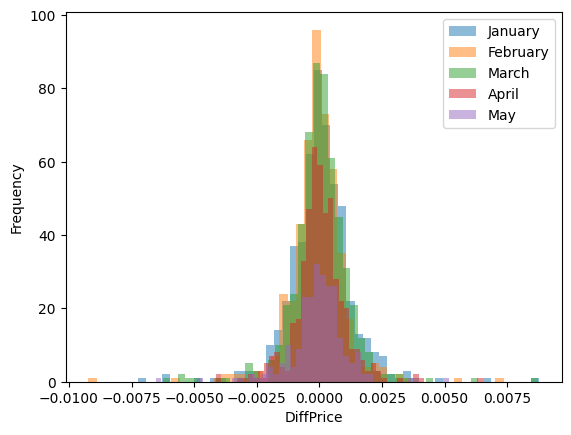

In [168]:
df_2023_grouped = (
    df_2023
    .sort("Time")
    .group_by(pl.col("Time").dt.month(), maintain_order=True)
)
months = {1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
          7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"}

for (month,), group in df_2023_grouped:
    label = months[month]
    plt.hist(group["DiffPrice"], bins=50, alpha=0.5, label=label)
#plt.title(f"Distribution of DiffPrice for Month {month}")
plt.xlabel("DiffPrice")
plt.ylabel("Frequency")
plt.legend()
plt.show()



# Data analysis with pandas

## 1. Leer los datos desde una página web.

In [169]:
data = pd.read_csv('https://archive.ics.uci.edu/static/public/17/data.csv')
data.head()

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## 2. Renombrar las columnas en formato PascalCase.

In [170]:
data.columns

Index(['ID', 'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3', 'Diagnosis'],
      dtype='str')

In [171]:
data.columns = [col.title().replace("_", "") for col in data.columns]
data.columns

Index(['Id', 'Radius1', 'Texture1', 'Perimeter1', 'Area1', 'Smoothness1',
       'Compactness1', 'Concavity1', 'ConcavePoints1', 'Symmetry1',
       'FractalDimension1', 'Radius2', 'Texture2', 'Perimeter2', 'Area2',
       'Smoothness2', 'Compactness2', 'Concavity2', 'ConcavePoints2',
       'Symmetry2', 'FractalDimension2', 'Radius3', 'Texture3', 'Perimeter3',
       'Area3', 'Smoothness3', 'Compactness3', 'Concavity3', 'ConcavePoints3',
       'Symmetry3', 'FractalDimension3', 'Diagnosis'],
      dtype='str')

## 3. Utilizar los métodos head(), tail(), describe() e info() para obtener información sobre el DataFrame.

In [172]:
data.head()

,Id,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [173]:
data.tail()

,Id,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M
568,92751,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,B


In [174]:
data.describe()

,Id,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Radius3,Texture3,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [175]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 569 non-null    int64  
 1   Radius1            569 non-null    float64
 2   Texture1           569 non-null    float64
 3   Perimeter1         569 non-null    float64
 4   Area1              569 non-null    float64
 5   Smoothness1        569 non-null    float64
 6   Compactness1       569 non-null    float64
 7   Concavity1         569 non-null    float64
 8   ConcavePoints1     569 non-null    float64
 9   Symmetry1          569 non-null    float64
 10  FractalDimension1  569 non-null    float64
 11  Radius2            569 non-null    float64
 12  Texture2           569 non-null    float64
 13  Perimeter2         569 non-null    float64
 14  Area2              569 non-null    float64
 15  Smoothness2        569 non-null    float64
 16  Compactness2       569 non-null    fl

## 4. Contabilizar la cantidad de valores nulos (null o NaN) en el DataFrame.

In [176]:
data.isna().sum()

Id                   0
Radius1              0
Texture1             0
Perimeter1           0
Area1                0
Smoothness1          0
Compactness1         0
Concavity1           0
ConcavePoints1       0
Symmetry1            0
FractalDimension1    0
Radius2              0
Texture2             0
Perimeter2           0
Area2                0
Smoothness2          0
Compactness2         0
Concavity2           0
ConcavePoints2       0
Symmetry2            0
FractalDimension2    0
Radius3              0
Texture3             0
Perimeter3           0
Area3                0
Smoothness3          0
Compactness3         0
Concavity3           0
ConcavePoints3       0
Symmetry3            0
FractalDimension3    0
Diagnosis            0
dtype: int64

No hay datos nulos, pero si hubiera propondria eliminarlos del data set y no tenerlos en cuenta dado que esta es informacion sensible y llenarlos por ejemplo con la media podria sesgar los resultados del analisis.

## 5. Identificar los valores únicos en la columna target que representan las etiquetas B y M (Benigno y Maligno, respectivamente).

In [177]:
data.columns

Index(['Id', 'Radius1', 'Texture1', 'Perimeter1', 'Area1', 'Smoothness1',
       'Compactness1', 'Concavity1', 'ConcavePoints1', 'Symmetry1',
       'FractalDimension1', 'Radius2', 'Texture2', 'Perimeter2', 'Area2',
       'Smoothness2', 'Compactness2', 'Concavity2', 'ConcavePoints2',
       'Symmetry2', 'FractalDimension2', 'Radius3', 'Texture3', 'Perimeter3',
       'Area3', 'Smoothness3', 'Compactness3', 'Concavity3', 'ConcavePoints3',
       'Symmetry3', 'FractalDimension3', 'Diagnosis'],
      dtype='str')

In [178]:
data["Diagnosis"].unique()

<ArrowStringArray>
['M', 'B']
Length: 2, dtype: str

## 6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería seaborn y el método countplot():

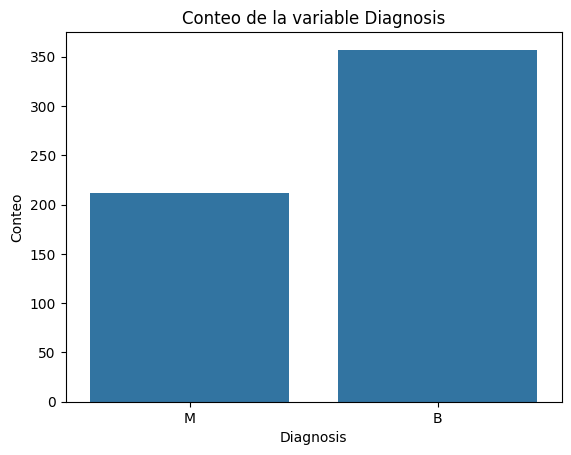

In [179]:
sns.countplot(data=data, x='Diagnosis')
plt.title('Conteo de la variable Diagnosis')
plt.ylabel('Conteo')
plt.xlabel('Diagnosis')
plt.show()

In [180]:
data.Diagnosis.value_counts()

Diagnosis
B    357
M    212
Name: count, dtype: int64

## 7. Agregar una nueva columna llamada DiagnosisNumeric donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).

In [181]:
data['DiagnosisNum'] = data['Diagnosis'].map({'M': 1, 'B': 0})
data.head()

,Id,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis,DiagnosisNum
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M,1
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M,1
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M,1
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M,1
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M,1


## 8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:

In [182]:
num_cols = data.select_dtypes(include=[np.number]).columns[ 1:]
num_cols

Index(['Radius1', 'Texture1', 'Perimeter1', 'Area1', 'Smoothness1',
       'Compactness1', 'Concavity1', 'ConcavePoints1', 'Symmetry1',
       'FractalDimension1', 'Radius2', 'Texture2', 'Perimeter2', 'Area2',
       'Smoothness2', 'Compactness2', 'Concavity2', 'ConcavePoints2',
       'Symmetry2', 'FractalDimension2', 'Radius3', 'Texture3', 'Perimeter3',
       'Area3', 'Smoothness3', 'Compactness3', 'Concavity3', 'ConcavePoints3',
       'Symmetry3', 'FractalDimension3', 'DiagnosisNum'],
      dtype='str')

In [183]:
data.head()

,Id,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis,DiagnosisNum
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M,1
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M,1
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M,1
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M,1
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M,1


In [184]:
num = data[num_cols]

means = num.mean()
stds = num.std()

data[num_cols] = (num - means) / stds
data.head()

,Id,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,...,Perimeter3,Area3,Smoothness3,Compactness3,Concavity3,ConcavePoints3,Symmetry3,FractalDimension3,Diagnosis,DiagnosisNum
0,842302,1.096100,-2.071512,1.268817,0.983510,1.567087,3.280628,2.650542,2.530249,2.215566,...,2.301575,1.999478,1.306537,2.614365,2.107672,2.294058,2.748204,1.935312,M,1.296535
1,842517,1.828212,-0.353322,1.684473,1.907030,-0.826235,-0.486643,-0.023825,0.547662,0.001391,...,1.533776,1.888827,-0.375282,-0.430066,-0.146620,1.086129,-0.243675,0.280943,M,1.296535
2,84300903,1.578499,0.455786,1.565126,1.557513,0.941382,1.052000,1.362280,2.035440,0.938859,...,1.346291,1.455004,0.526944,1.081980,0.854222,1.953282,1.151242,0.201214,M,1.296535
3,84348301,-0.768233,0.253509,-0.592166,-0.763792,3.280667,3.399917,1.914213,1.450431,2.864862,...,-0.249720,-0.549538,3.391291,3.889975,1.987839,2.173873,6.040726,4.930672,M,1.296535
4,84358402,1.748758,-1.150804,1.775011,1.824624,0.280125,0.538866,1.369806,1.427237,-0.009552,...,1.337363,1.219651,0.220362,-0.313119,0.612640,0.728618,-0.867590,-0.396751,M,1.296535


## 9. Agrupar características similares y calcular su promedio.

In [185]:
data.columns

Index(['Id', 'Radius1', 'Texture1', 'Perimeter1', 'Area1', 'Smoothness1',
       'Compactness1', 'Concavity1', 'ConcavePoints1', 'Symmetry1',
       'FractalDimension1', 'Radius2', 'Texture2', 'Perimeter2', 'Area2',
       'Smoothness2', 'Compactness2', 'Concavity2', 'ConcavePoints2',
       'Symmetry2', 'FractalDimension2', 'Radius3', 'Texture3', 'Perimeter3',
       'Area3', 'Smoothness3', 'Compactness3', 'Concavity3', 'ConcavePoints3',
       'Symmetry3', 'FractalDimension3', 'Diagnosis', 'DiagnosisNum'],
      dtype='str')

In [186]:
lista = ['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]

In [187]:
for param in lista:
    data[param] = data[data.columns[data.columns.str.startswith(param.replace("Mean", ""))]].mean(axis=1)
data[lista].head()

,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean
0,1.822892,-1.331460,2.133644,1.822793,0.886604,2.403566,1.827201,1.828182,2.037172,1.698454
1,1.377122,-0.532558,1.160448,1.512536,-0.602112,-0.536342,-0.203612,0.631241,-0.349009,-0.228767
2,1.438879,-0.115855,1.253866,1.397605,0.390527,0.982746,0.809797,1.804099,0.775643,0.032286
3,-0.241121,0.092354,-0.185181,-0.533818,2.453684,3.343920,1.573617,1.579444,4.544703,3.960995
4,1.438539,-1.135278,1.461481,1.411195,0.660750,0.059090,0.936729,1.099685,-0.412639,-0.153272


## 10. Crear un gráfico donde se muestre el histograma de la columna RadiusMean separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

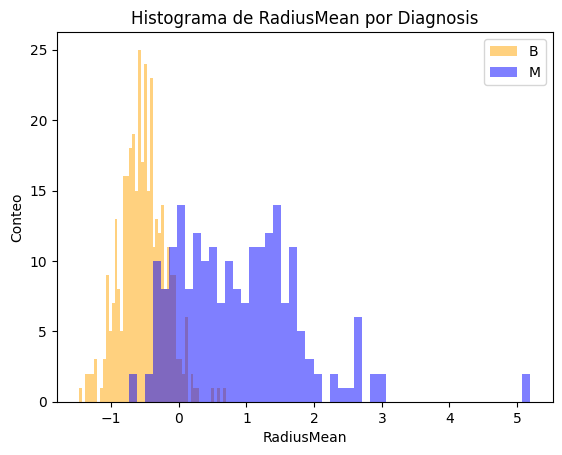

In [188]:
colors = {'B': 'orange', 'M': 'blue'}

for diag, subset in data.groupby('Diagnosis'):
    plt.hist(subset['RadiusMean'], bins=50, alpha=0.5, color=colors[diag], label=diag)
plt.title('Histograma de RadiusMean por Diagnosis')
plt.ylabel('Conteo')
plt.xlabel('RadiusMean')
plt.legend()
plt.show()

## 11. Generar gráficos de violín para múltiples características.

In [189]:
import re
obj = """- `RadiusMean`
   - `TextureMean`
   - `PerimeterMean`
   - `AreaMean`
   - `SmoothnessMean`
   - `CompactnessMean`
   - `ConcavityMean`
   - `ConcavePointsMean`
   - `Symmetry3`
   - `FractalDimension3`"""
vars = re.findall(r'`([^`]+)`', obj)
vars

['RadiusMean',
 'TextureMean',
 'PerimeterMean',
 'AreaMean',
 'SmoothnessMean',
 'CompactnessMean',
 'ConcavityMean',
 'ConcavePointsMean',
 'Symmetry3',
 'FractalDimension3']

In [190]:
melted = pd.melt(data, id_vars=['Diagnosis'], value_vars=vars, var_name='Feature', value_name='Value')
melted

,Diagnosis,Feature,Value
0,M,RadiusMean,1.822892
1,M,RadiusMean,1.377122
2,M,RadiusMean,1.438879
3,M,RadiusMean,-0.241121
4,M,RadiusMean,1.438539
...,...,...,...
5685,M,FractalDimension3,-0.708467
5686,M,FractalDimension3,-0.973122
5687,M,FractalDimension3,-0.318129
5688,M,FractalDimension3,2.217684


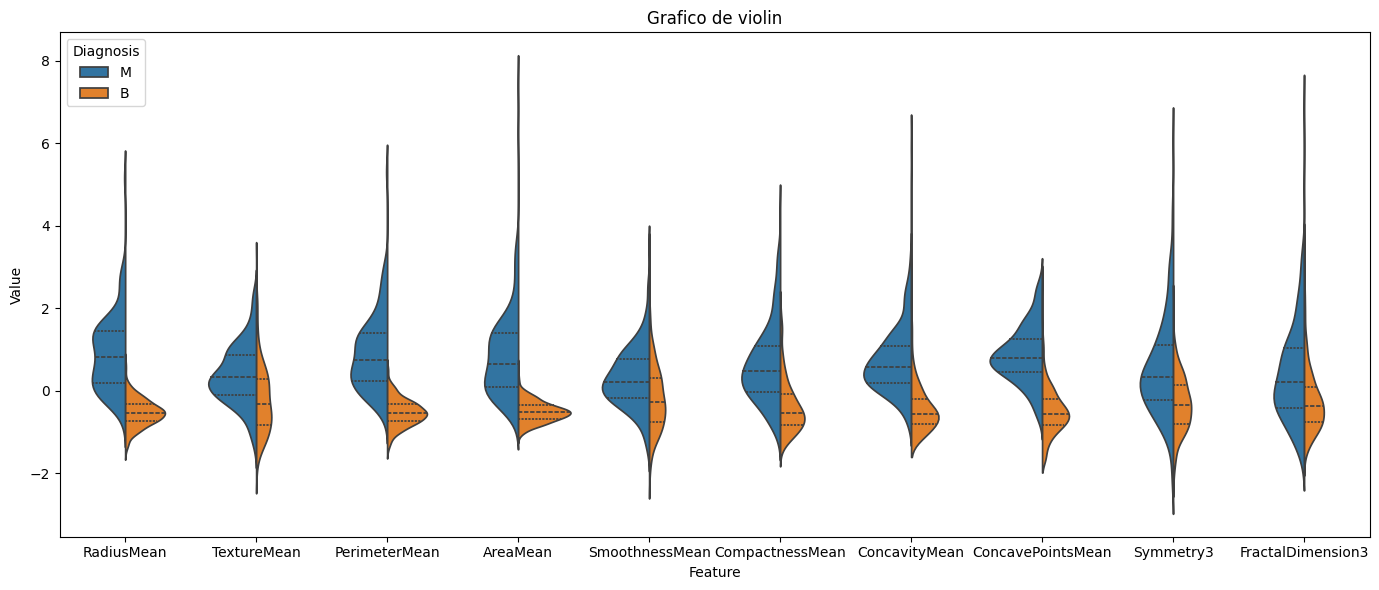

In [191]:
fig = plt.figure(figsize=(14, 6))
sns.violinplot(x='Feature', y='Value', hue='Diagnosis', data=melted, split=True, inner='quartile')
plt.title('Grafico de violin')
plt.tight_layout()
plt.show()

## 12. Determinar y eliminar los valores atípicos (outliers) en la columna RadiusMean.

<Axes: title={'center': 'RadiusMean'}, xlabel='Diagnosis'>

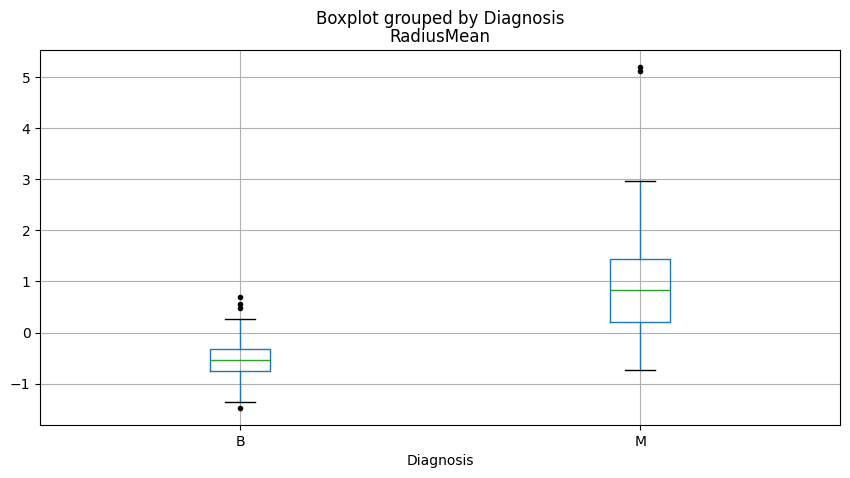

In [192]:
data.boxplot(column='RadiusMean', by='Diagnosis', sym='k.', figsize=(10, 5))

<Axes: title={'center': 'RadiusMean'}, xlabel='Diagnosis'>

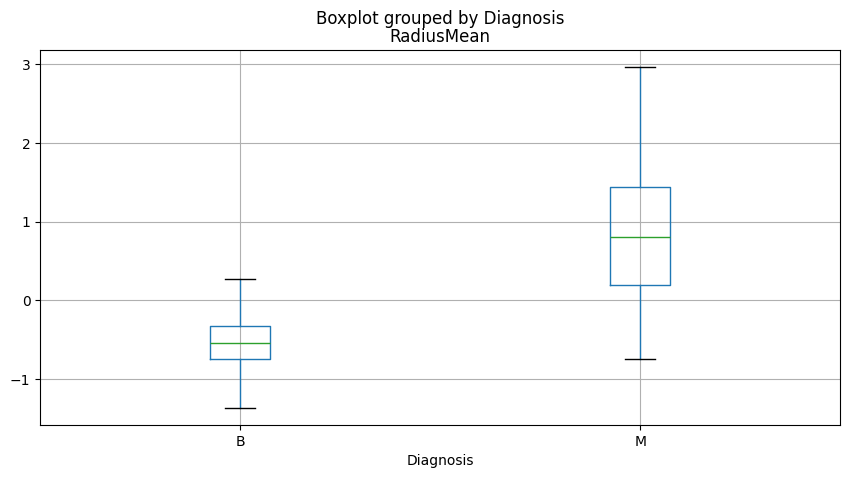

In [193]:
col = 'RadiusMean'
Q1 = data.groupby('Diagnosis')[col].transform(lambda x: x.quantile(0.25))
Q3 = data.groupby('Diagnosis')[col].transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1

mask = data[col].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

data = data[mask]

data.boxplot(column='RadiusMean', by='Diagnosis', sym='k.', figsize=(10, 5))

## 13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

In [194]:
num_cols = data.select_dtypes(include=[np.number]).columns[1:]
data[num_cols].corr()

,Radius1,Texture1,Perimeter1,Area1,Smoothness1,Compactness1,Concavity1,ConcavePoints1,Symmetry1,FractalDimension1,...,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,FractalDimensionMean
Radius1,1.000000,0.324276,0.997759,0.990452,0.172718,0.507371,0.665334,0.818758,0.157234,-0.298503,...,0.954760,0.207851,0.948315,0.950848,0.029145,0.413019,0.501925,0.719460,0.091365,-0.118811
Texture1,0.324276,1.000000,0.329799,0.325790,-0.025181,0.231143,0.297045,0.288801,0.065061,-0.073941,...,0.349030,0.907841,0.354995,0.337580,0.024449,0.250880,0.265619,0.271142,0.072225,0.036741
Perimeter1,0.997759,0.329799,1.000000,0.989082,0.210236,0.559582,0.706092,0.848201,0.193316,-0.246953,...,0.958171,0.216739,0.957982,0.952945,0.065923,0.464477,0.543372,0.752546,0.125769,-0.068233
Area1,0.990452,0.325790,0.989082,1.000000,0.175699,0.503880,0.674355,0.823361,0.162511,-0.272231,...,0.961437,0.218993,0.954237,0.971417,0.052390,0.408942,0.506768,0.715862,0.098195,-0.099934
Smoothness1,0.172718,-0.025181,0.210236,0.175699,1.000000,0.662840,0.525881,0.558678,0.559140,0.588321,...,0.250380,0.033205,0.270806,0.223706,0.878032,0.533905,0.443504,0.541111,0.466094,0.521926
Compactness1,0.507371,0.231143,0.559582,0.503880,0.662840,1.000000,0.886953,0.833459,0.605872,0.575577,...,0.562714,0.206853,0.623000,0.532936,0.563686,0.947461,0.828841,0.849677,0.545988,0.668156
Concavity1,0.665334,0.297045,0.706092,0.674355,0.525881,0.886953,1.000000,0.918645,0.510340,0.359324,...,0.709048,0.267288,0.750002,0.691441,0.445117,0.846894,0.942714,0.915489,0.448840,0.509509
ConcavePoints1,0.818758,0.288801,0.848201,0.823361,0.558678,0.833459,0.918645,1.000000,0.472053,0.184624,...,0.848812,0.239481,0.873253,0.831272,0.430484,0.727796,0.768604,0.938256,0.385234,0.312863
Symmetry1,0.157234,0.065061,0.193316,0.162511,0.559140,0.605872,0.510340,0.472053,1.000000,0.482145,...,0.246227,0.109584,0.275859,0.213440,0.482624,0.547313,0.470969,0.483666,0.872784,0.474848
FractalDimension1,-0.298503,-0.073941,-0.246953,-0.272231,0.588321,0.575577,0.359324,0.184624,0.482145,1.000000,...,-0.189060,0.017025,-0.134641,-0.202253,0.616283,0.584567,0.429583,0.269916,0.468679,0.924778


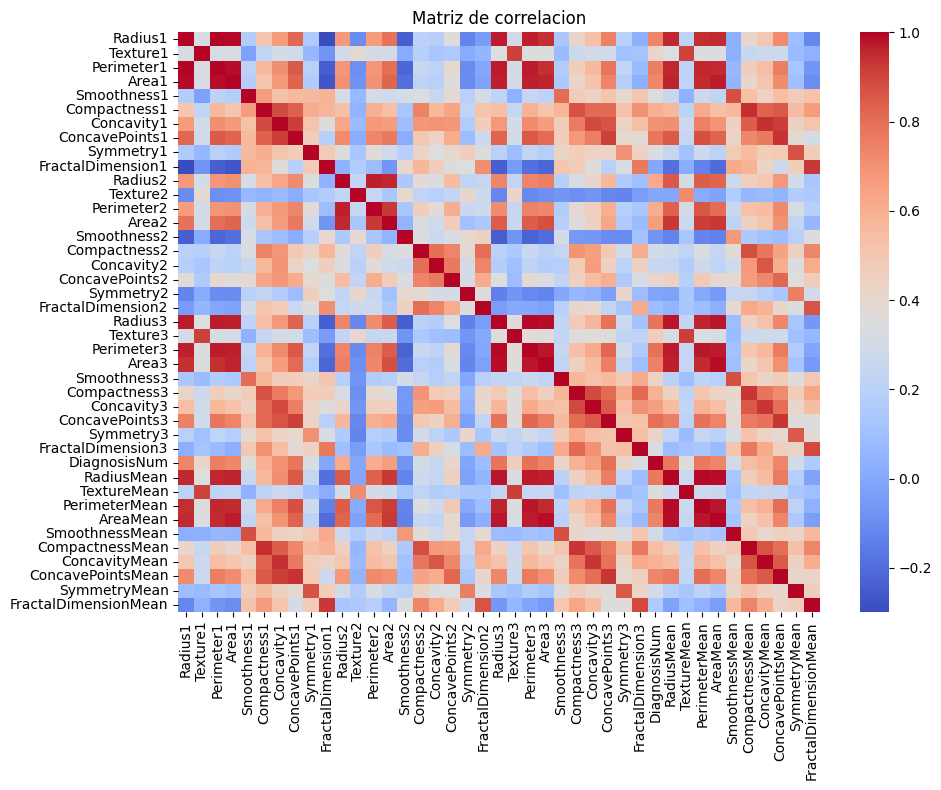

In [195]:
fig = plt.figure(figsize=(10, 8))
sns.heatmap(data[num_cols].corr(), cmap='coolwarm')
plt.title('Matriz de correlacion')
plt.tight_layout()
plt.show()

## 14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?
Puede utilizarse graficas pairplot con las cuales es posible visualizar las relaciones entre parejas de variables que componen el dataset.

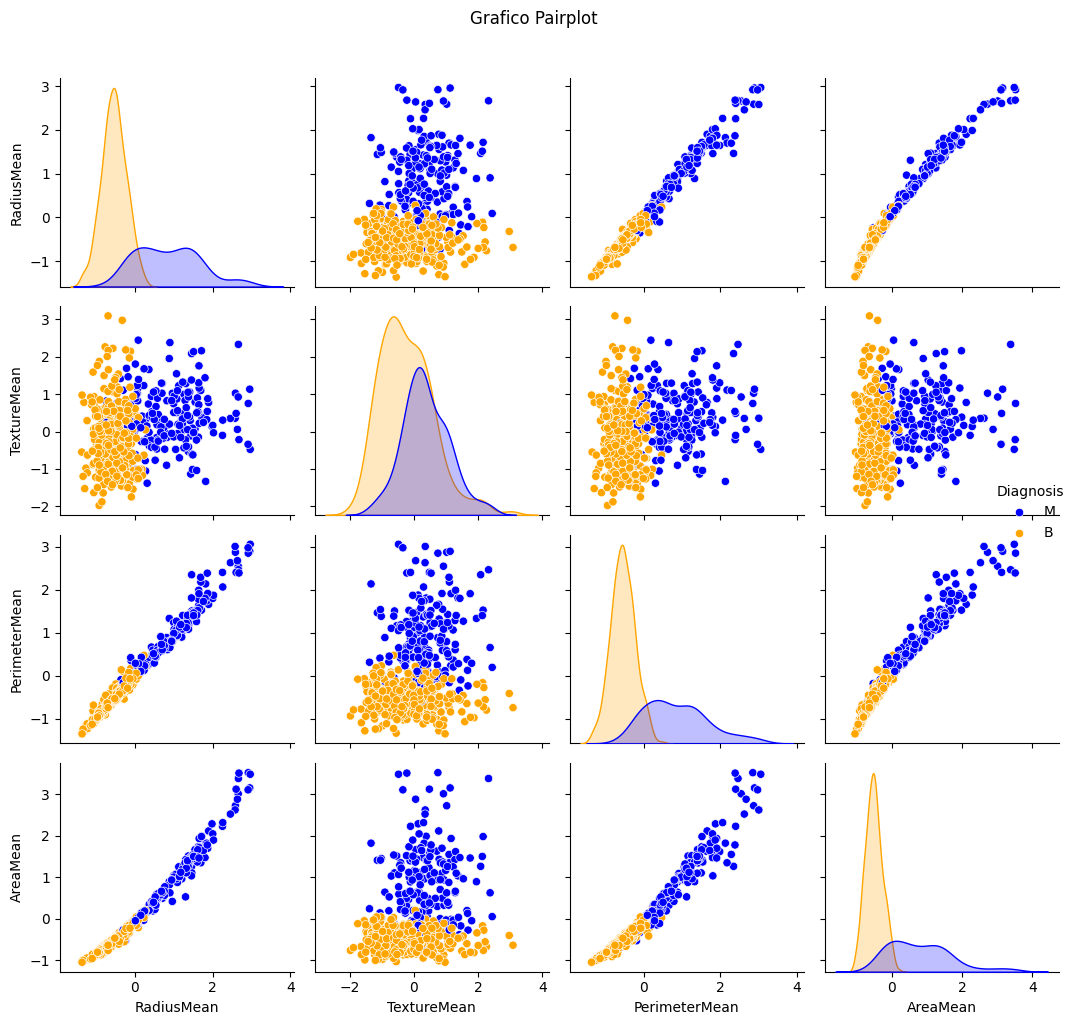

In [196]:
features = ['RadiusMean','TextureMean','PerimeterMean','AreaMean']
sns.pairplot(data[features + ['Diagnosis']], hue='Diagnosis', palette={'B':'orange','M':'blue'}, diag_kind='kde')
plt.suptitle('Grafico Pairplot', y=1.02)
plt.tight_layout()
plt.show()